In [1]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import seaborn as sns
from astropy.io import fits
from matplotlib import pyplot as plt

#from pipeline_config import MAPS_DIR

In [2]:
datasets = [
     {
        "instrument": "MUSE",
        "line": "Halpha",
        "filename": "MUSE-M42-H-bin2_trim-ivsv.fits",
        "label": r"H$\alpha$",
    },
    {
        "instrument": "MUSE",
        "line": "NII_6583",
        "filename": "MUSE-M42-N-bin2_trim-ivsv.fits",
        "label": r"[N II] $\lambda$6583",
    },
    {
        "instrument": "MUSE",
        "line": "OIII_5007",
        "filename": "MUSE-M42-O-bin2_trim-ivsv.fits",
        "label": r"[O III] $\lambda$5007",
    },
    {
        "instrument": "MUSE",
        "line": "Halpha",
        "filename": "MUSE-M42-H-bin2-ivsv.fits",
        "label": r"H$\alpha$",
    },
    {
        "instrument": "MUSE",
        "line": "NII_6583",
        "filename": "MUSE-M42-N-bin2-ivsv.fits",
        "label": r"[N II] $\lambda$6583",
    },
    {
        "instrument": "MUSE",
        "line": "OIII_5007",
        "filename": "MUSE-M42-O-bin2-ivsv.fits",
        "label": r"[O III] $\lambda$5007",
    },
    {
        "instrument": "KPNO",
        "line": "Halpha",
        "filename": "KPNO-M42-H-bin0-ivsv.fits",
        "label": r"H$\alpha$",
    },
    {
        "instrument": "KPNO",
        "line": "NII_6583",
        "filename": "KPNO-M42-N-bin0-ivsv.fits",
        "label": r"[N II] $\lambda$6583",
    },
    {
        "instrument": "KPNO",
        "line": "OIII_5007",
        "filename": "KPNO-M42-O-bin0-ivsv.fits",
        "label": r"[O III] $\lambda$5007",
    },
]

In [3]:
def load_velocity_dataset(entry):
    fits_path = entry["filename"]

    with fits.open(fits_path) as hdul:
        sb = hdul["MOM0"].data.astype(float)
        vv = hdul["MOM1"].data.astype(float)
#        mask = hdul["MASK"].data.astype(bool)

    #sb = np.where(mask, sb, np.nan)
    #vv = np.where(mask, vv, np.nan)

    df = pd.DataFrame({
        "X": np.indices(vv.shape)[0].ravel(),
        "Y": np.indices(vv.shape)[1].ravel(),
        "VV": vv.ravel(),
        "SB": sb.ravel(),
#        "mask": mask.ravel(),
    })

    df = df.dropna(subset=["VV"])

    df["instrument"] = entry["instrument"]
    df["line"] = entry["line"]
    df["label"] = entry["label"]
    df["filename"] = entry["filename"]

    mean_v = df["VV"].mean()
    df["RV_centered"] = df["VV"] - mean_v

    raw = {
        "sb": sb,
        "vv": vv,
#        "mask": mask,
        "instrument": entry["instrument"],
        "line": entry["line"],
        "label": entry["label"],
        "filename": entry["filename"],
    }

    return df, raw

In [4]:
processed_list = []
raw_data = {}

for entry in datasets:
    df, raw = load_velocity_dataset(entry)
    processed_list.append(df)

    key = (entry["line"], entry["instrument"])
    raw_data[key] = raw

processed_data = pd.concat(processed_list, ignore_index=True)

In [5]:
processed_data.head()

,X,Y,VV,SB,instrument,line,label,filename,RV_centered
0,0,0,12.632797,2.386239e+06,MUSE,Halpha,H$\alpha$,MUSE-M42-H-bin2_trim-ivsv.fits,-1.827834
1,0,1,12.747056,2.339319e+06,MUSE,Halpha,H$\alpha$,MUSE-M42-H-bin2_trim-ivsv.fits,-1.713575
2,0,2,12.409716,2.268610e+06,MUSE,Halpha,H$\alpha$,MUSE-M42-H-bin2_trim-ivsv.fits,-2.050915
3,0,3,11.973459,2.276410e+06,MUSE,Halpha,H$\alpha$,MUSE-M42-H-bin2_trim-ivsv.fits,-2.487172
4,0,4,12.477502,2.312765e+06,MUSE,Halpha,H$\alpha$,MUSE-M42-H-bin2_trim-ivsv.fits,-1.983129


In [6]:
processed_data.groupby(["line", "instrument"])["VV"].describe()

count       mean        std         min        25%  \
line      instrument                                                          
Halpha    KPNO        182115.0  16.777023   3.050651   -6.101346  15.028402   
          MUSE        239381.0  14.239308  20.116838 -523.527994  12.428239   
NII_6583  KPNO        182115.0  20.480622   2.987761  -11.725923  18.619284   
          MUSE        239369.0  17.303249   4.802712 -418.072109  15.332651   
OIII_5007 KPNO        182984.0  16.244701   2.799948   -0.819397  14.684063   
          MUSE        239419.0  10.730290  25.869902 -222.576983   9.161856   

                            50%        75%           max  
line      instrument                                      
Halpha    KPNO        17.188578  18.844733     24.722612  
          MUSE        14.223690  16.137292   9720.719208  
NII_6583  KPNO        20.319458  21.949148     43.134998  
          MUSE        17.254848  19.187593   1626.566102  
OIII_5007 KPNO        16.155788  18.008946     25.508438  
          MUSE        10.731426  12.363988  12443.680569

In [7]:
processed_data

,X,Y,VV,SB,instrument,line,label,filename,RV_centered
0,0,0,12.632797,2.386239e+06,MUSE,Halpha,H$\alpha$,MUSE-M42-H-bin2_trim-ivsv.fits,-1.827834e+00
1,0,1,12.747056,2.339319e+06,MUSE,Halpha,H$\alpha$,MUSE-M42-H-bin2_trim-ivsv.fits,-1.713575e+00
2,0,2,12.409716,2.268610e+06,MUSE,Halpha,H$\alpha$,MUSE-M42-H-bin2_trim-ivsv.fits,-2.050915e+00
3,0,3,11.973459,2.276410e+06,MUSE,Halpha,H$\alpha$,MUSE-M42-H-bin2_trim-ivsv.fits,-2.487172e+00
4,0,4,12.477502,2.312765e+06,MUSE,Halpha,H$\alpha$,MUSE-M42-H-bin2_trim-ivsv.fits,-1.983129e+00
...,...,...,...,...,...,...,...,...,...
1265378,513,351,14.191357,1.156602e-01,KPNO,OIII_5007,[O III] $\lambda$5007,KPNO-M42-O-bin0-ivsv.fits,-2.053345e+00
1265379,513,352,14.151466,1.144899e-01,KPNO,OIII_5007,[O III] $\lambda$5007,KPNO-M42-O-bin0-ivsv.fits,-2.093235e+00
1265380,513,353,16.244701,0.000000e+00,KPNO,OIII_5007,[O III] $\lambda$5007,KPNO-M42-O-bin0-ivsv.fits,-3.552714e-15
1265381,513,354,16.244701,0.000000e+00,KPNO,OIII_5007,[O III] $\lambda$5007,KPNO-M42-O-bin0-ivsv.fits,-3.552714e-15


In [8]:
ha_muse_trim = processed_data[
    (processed_data["filename"] == "MUSE-M42-H-bin2_trim-ivsv.fits")
]

ha_muse = processed_data[
    (processed_data["filename"] == "MUSE-M42-H-bin2-ivsv.fits")
]

ha_kpno = processed_data[
    (processed_data["filename"] == "KPNO-M42-H-bin0-ivsv.fits")
]

n_muse_trim = processed_data[
    (processed_data["filename"] == "MUSE-M42-N-bin2_trim-ivsv.fits")
]

n_muse = processed_data[
    (processed_data["filename"] == "MUSE-M42-N-bin2-ivsv.fits")
]

n_kpno = processed_data[
    (processed_data["filename"] == "KPNO-M42-N-bin0-ivsv.fits")
]

o_muse_trim = processed_data[
    (processed_data["filename"] == "MUSE-M42-O-bin2_trim-ivsv.fits")
]

o_muse = processed_data[
    (processed_data["filename"] == "MUSE-M42-O-bin2-ivsv.fits")
]

o_kpno = processed_data[
    (processed_data["filename"] == "KPNO-M42-O-bin0-ivsv.fits")
]

In [9]:
ha_muse_trim.SB.max()

42426444.25

In [10]:
ha_muse_trim.SB.median()

6417778.53125

In [11]:
instrument_colors = {
    "MUSE": "black",
    "KPNO": "darkgray",
}

line_order = [
    "Halpha",
    "NII_6583",
    "OIII_5007",
    "SIII_9069",
    "SII_6731",
    "ArIII_7136",
]

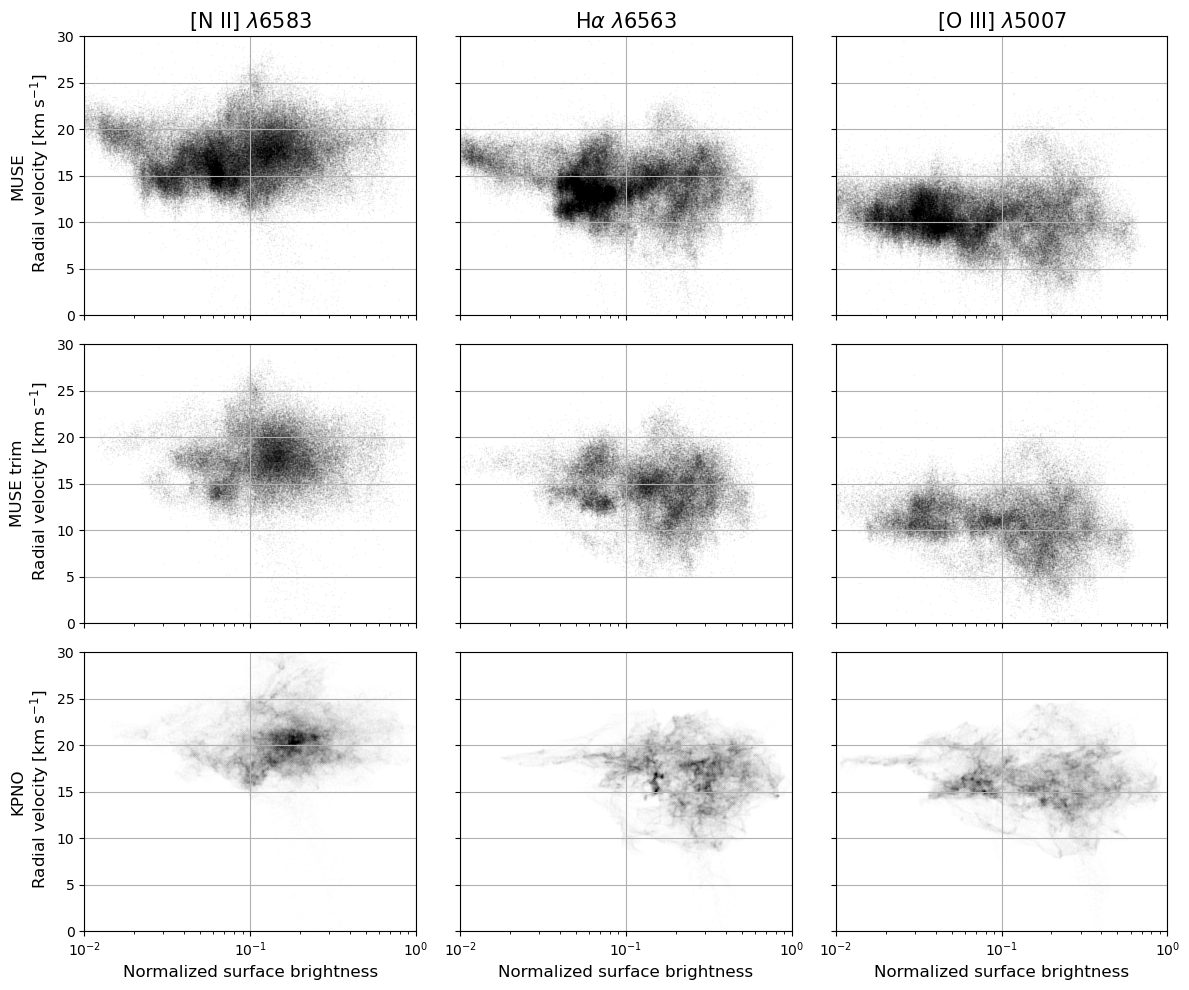

In [12]:
import numpy as np
import matplotlib.pyplot as plt

datasets = {
    "MUSE": {
        "N": n_muse,
        "H": ha_muse,
        "O": o_muse,
    },
    "MUSE trim": {
        "N": n_muse_trim,
        "H": ha_muse_trim,
        "O": o_muse_trim,
    },
    "KPNO": {
        "N": n_kpno,
        "H": ha_kpno,
        "O": o_kpno,
    },
}

rows = ["MUSE", "MUSE trim", "KPNO"]
cols = ["N", "H", "O"]

alpha_values = {
    "MUSE": 0.05,
    "MUSE trim": 0.05,
    "KPNO": 0.005,
}

size_values = {
    "MUSE": 5,
    "MUSE trim": 5,
    "KPNO":15,
}

col_titles = {
    "N": r"[N II] $\lambda$6583",
    "H": r"H$\alpha$ $\lambda$6563",
    "O": r"[O III] $\lambda$5007",
}

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(12, 10),
    sharex=True,
    sharey=True,
)

for i, row in enumerate(rows):
    for j, col in enumerate(cols):

        ax = axes[i, j]
        data = datasets[row][col]

        x = data["SB"] / data["SB"].max()
        y = data["VV"]

        ax.scatter(
            x,
            y,
            alpha=alpha_values[row],
            marker=".",
            color="k",
            linewidths=0,
            s=size_values[row]
        )

        ax.set_xlim(1e-2, 1)
        ax.set_ylim(0, 30)

        # Since SB/SBmax spans 0.01 to 1, log scale is useful
        ax.set_xscale("log")
        ax.grid(True)
        if i == 0:
            ax.set_title(col_titles[col], fontsize=15)

        if j == 0:
            ax.set_ylabel(
                #fr"{row}\nRadial velocity [km s$^{{-1}}$]",
                f"{row}" + '\n '+r'Radial velocity [km s$^{-1}$]',
                fontsize=12
            )

        if i == 2:
            ax.set_xlabel(
                "Normalized surface brightness",
                fontsize=12
            )

    
    
#plt.savefig(
#    "SB_vs_radial_velocity_grid.pdf",
#    dpi=300,
#    bbox_inches="tight"
#)
plt.tight_layout()
plt.show()

Histogram

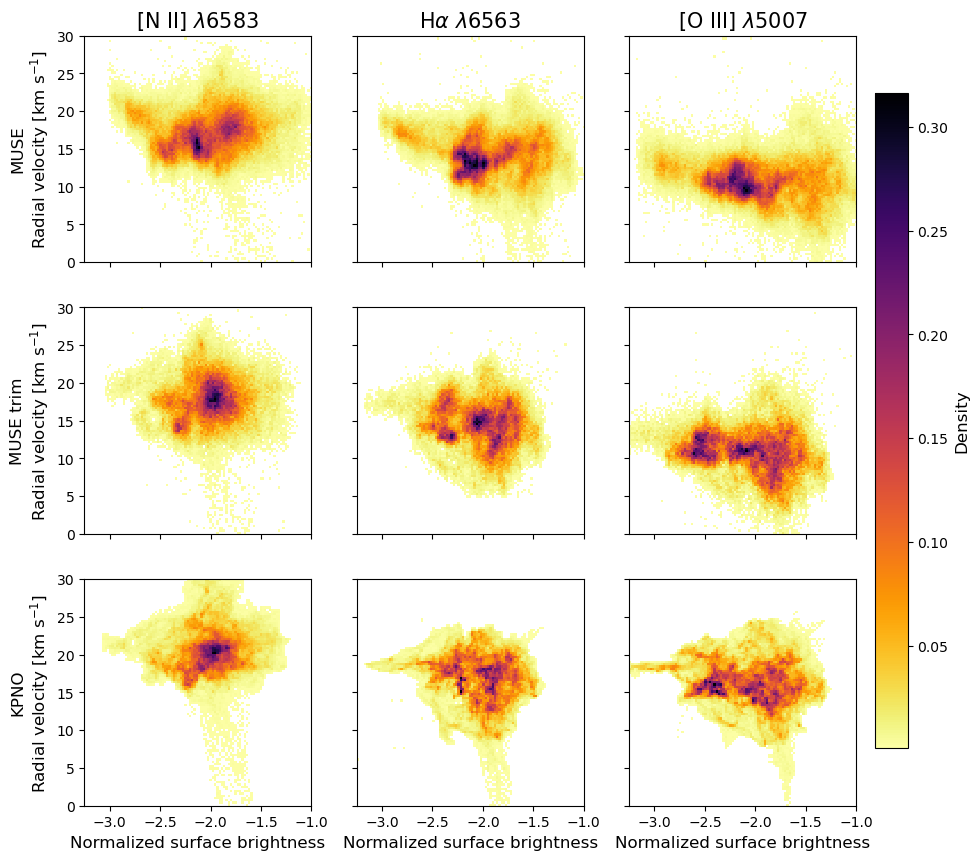

In [28]:
import numpy as np
import matplotlib.pyplot as plt

datasets = {
    "MUSE": {
        "N": n_muse,
        "H": ha_muse,
        "O": o_muse,
    },
    "MUSE trim": {
        "N": n_muse_trim,
        "H": ha_muse_trim,
        "O": o_muse_trim,
    },
    "KPNO": {
        "N": n_kpno,
        "H": ha_kpno,
        "O": o_kpno,
    },
}

rows = ["MUSE", "MUSE trim", "KPNO"]
cols = ["N", "H", "O"]

col_titles = {
    "N": r"[N II] $\lambda$6583",
    "H": r"H$\alpha$ $\lambda$6563",
    "O": r"[O III] $\lambda$5007",
}

# Equivalent to SB/SBmax from 1e-2 to 1
xrange = [-3.25, -1.0]

# Same velocity range as your scatter plot
yrange = [0, 30]

bins = 100   

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(12, 10),
    sharex=True,
    sharey=True,
)

im = None

for i, row in enumerate(rows):
    for j, col in enumerate(cols):

        ax = axes[i, j]
        data = datasets[row][col]

        SB = np.asarray(data["SB"])
        VV = np.asarray(data["VV"])

        mask = (
            np.isfinite(SB) &
            np.isfinite(VV) &
            (SB > 0) &
            (np.nanmax(SB) > 0)
        )

        SB_norm = SB[mask] / (np.nanmedian(SB[mask])*100)
        VV_valid = VV[mask]

        x = np.log10(SB_norm)
        y = VV_valid

        H, xedges, yedges = np.histogram2d(
            x,
            y,
            bins=bins,
            range=[xrange, yrange],
            density=True,
        )

        HH = np.where(H == 0, np.nan, H)

        im = ax.imshow(
            HH.T,
            origin="lower",
            aspect="auto",
            cmap="inferno_r",
            extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
            interpolation="none",
        )

        ax.grid(False)

        if i == 0:
            ax.set_title(col_titles[col], fontsize=15)

        if j == 0:
            ax.set_ylabel(
                f"{row}" + "\n" + r"Radial velocity [km s$^{-1}$]",
                fontsize=12,
            )

        if i == 2:
            ax.set_xlabel(
                #r"$\log_{10}(\mathrm{SB}/\mathrm{SB}_{\max})$",
                "Normalized surface brightness",
                fontsize=12,
            )

        ax.set_xlim(xrange)
        ax.set_ylim(yrange)

# One shared colorbar
cbar = fig.colorbar(
    im,
    ax=axes,
    shrink=0.85,
    pad=0.02,
)

cbar.set_label("Density", fontsize=12)

plt.savefig(
    "SB_vs_radial_velocity_grid.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [14]:
SB = np.asarray(ha_kpno.SB)
VV = np.asarray(ha_kpno.VV)

mask = (
    np.isfinite(SB) &
    np.isfinite(VV) &
    (SB > 0)
)

x = np.log10(SB[mask])
y = VV[mask]

xmin, xmax = x.min(), x.max()
ymin, ymax = y.min(), y.max()



H, xedges, yedges = np.histogram2d(
    x,
    y,
    bins=1000,
    range=[[xmin, xmax], [ymin, ymax]],
    density=True,
)

HH = np.where(H == 0, np.nan, H)

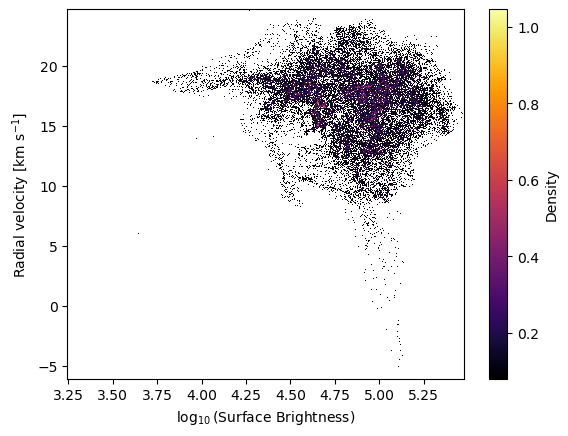

In [15]:
plt.imshow(
    HH.T,
    origin="lower",
    aspect="auto",
    cmap="inferno",
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    #aspect = 'auto',
    interpolation = 'none'
)

plt.xlabel(r"$\log_{10}(\mathrm{Surface\ Brightness})$")
plt.ylabel(r"Radial velocity [km s$^{-1}$]")
plt.colorbar(label="Density")
plt.show()